# **TIỀN XỬ LÝ & KHÁM PHÁ DỮ LIỆU**
## **Phần 1: Tiền xử lý dữ liệu (Data Preprocessing)**
### 1. Import các thư viện cần thiết và đọc dữ liệu

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
# Load dữ liệu
DATA_IN = Path("../data/raw/fact_product_tiki_20260331_tuan.csv")
DATA_OUT = Path("../data/processed/tiki_data.csv")
try:
    df = pd.read_csv(DATA_IN)
    print(f" Load thành công: {DATA_IN.name} ({len(df)} dòng)")
except FileNotFoundError:
    print(f" Lỗi: Không tìm thấy file tại {DATA_IN}")
except Exception as e:
    print(f" Lỗi không xác định: {e}")

 Load thành công: fact_product_tiki_20260331_tuan.csv (5765 dòng)


### 2. Kiểm tra tính nhất quán & Trùng lặp
- **Mục tiêu:** loại bỏ dữ liệu trùng lặp và chuẩn hóa logic giá bán để đảm bảo tính nhất quán cho tập dữ liệu phân tích.

In [4]:
# Loại bỏ trùng lặp
before_dedup = len(df)
df.drop_duplicates(subset=['product_id'], inplace=True)
after_dedup = len(df)
print(f" Đã loại bỏ {before_dedup - after_dedup} dòng trùng lặp. Còn lại {after_dedup} dòng.")

# Sửa lỗi logic giá (Giá gốc < Giá hiện tại)
price_errors = (df['price_original'] < df['price_current']).sum()
df['price_original'] = df[['price_original', 'price_current']].max(axis=1)
print(f" Đã sửa lỗi logic giá cho {price_errors} sản phẩm.")

 Đã loại bỏ 20 dòng trùng lặp. Còn lại 5745 dòng.
 Đã sửa lỗi logic giá cho 0 sản phẩm.


### 3. Xử lý giá trị thiếu (Missing Values)
- **Mục tiêu:** xử lý các giá trị thiếu và loại bỏ các bản ghi không hợp lệ nhằm đảm bảo tính đầy đủ và sẵn sàng của tập dữ liệu cho phân tích

In [5]:
# Xử lý giá trị thiếu 
cols_fill_zero = ['rating', 'review_count', 'sold_count', 'discount_percent']

# Đếm tổng số giá trị rỗng trước khi điền
total_filled = df[cols_fill_zero].isna().sum().sum()
df[cols_fill_zero] = df[cols_fill_zero].fillna(0)
print(f" Đã điền '0' cho {total_filled} giá trị trống (rating, sold,...) ")

# Xóa dòng không có tên SP
before_rows = len(df)
df.dropna(subset=['product_name'], inplace=True)
after_rows = len(df)
print(f" Đã loại bỏ {before_rows - after_rows} dòng thiếu 'product_name'. Còn lại {after_rows} dòng.")

 Đã điền '0' cho 6873 giá trị trống (rating, sold,...) 
 Đã loại bỏ 0 dòng thiếu 'product_name'. Còn lại 5745 dòng.


### 4. Chuyển đổi kiểu dữ liệu
- **Mục tiêu:** chuẩn hóa và tối ưu hóa kiểu dữ liệu cho các biến số, thời gian và phân loại để đảm bảo tính tương thích và hiệu suất cao nhất khi huấn luyện mô hình.

In [6]:
# Chuyển đổi sang số 
float_cols = ['price_current', 'price_original', 'discount_percent', 'rating']
df[float_cols] = df[float_cols].apply(pd.to_numeric, errors='coerce')

# Chuyển đổi sang số nguyên
int_cols = ['sold_count', 'review_count']
df[int_cols] = df[int_cols].fillna(0).astype(int)

# Chuyển đổi Boolean 
bool_cols = ['is_freeship', 'price_ends_with_9', 'has_video']
for col in bool_cols:
    df[col] = df[col].astype(bool)

# Chuyển đổi Thời gian
df['crawled_at'] = pd.to_datetime(df['crawled_at'])

# Tối ưu bộ nhớ cho ID 
df['category_id'] = df['category_id'].astype('category')

print("✔ Hoàn tất chuẩn hóa kiểu dữ liệu cho Model.")
df.info() 
df.to_csv(DATA_OUT, index=False, encoding='utf-8-sig')

✔ Hoàn tất chuẩn hóa kiểu dữ liệu cho Model.
<class 'pandas.core.frame.DataFrame'>
Index: 5745 entries, 0 to 5764
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype                    
---  ------                      --------------  -----                    
 0   product_id                  5745 non-null   object                   
 1   platform_id                 5745 non-null   object                   
 2   category_id                 5745 non-null   category                 
 3   shop_id                     5745 non-null   object                   
 4   product_name                5745 non-null   object                   
 5   product_url                 5745 non-null   object                   
 6   price_current               5745 non-null   float64                  
 7   price_original              5745 non-null   float64                  
 8   discount_percent            5745 non-null   float64                  
 9   price_ends_with_9      

## **Phần 2: Khám phá dữ liệu (EDA)**
### 1. Thống kê mô tả

In [7]:
df[['price_current', 'sold_count', 'rating']].describe()

,price_current,sold_count,rating
count,5.745000e+03,5745.000000,5745.000000
mean,2.320329e+06,78.339252,1.853734
std,7.557256e+06,686.546463,2.306019
min,3.900000e+03,0.000000,0.000000
25%,1.581000e+05,0.000000,0.000000
50%,4.650000e+05,2.000000,0.000000
75%,1.590000e+06,13.000000,4.700000
max,1.655500e+08,32562.000000,5.000000


### 2. Phân tích Đề xuất 1: Tối ưu hóa Giá bán
- **Mục tiêu:** tìm ra mối quan hệ giữa giá và lượng cầu, từ đó xác định khoảng giá phù hợp.

In [8]:
# Cấu hình cho biểu đồ
sns.set_theme(style="ticks", palette="pastel")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

#### a. Biểu đồ Tương quan Biến thiên (Price vs. Sold Count)

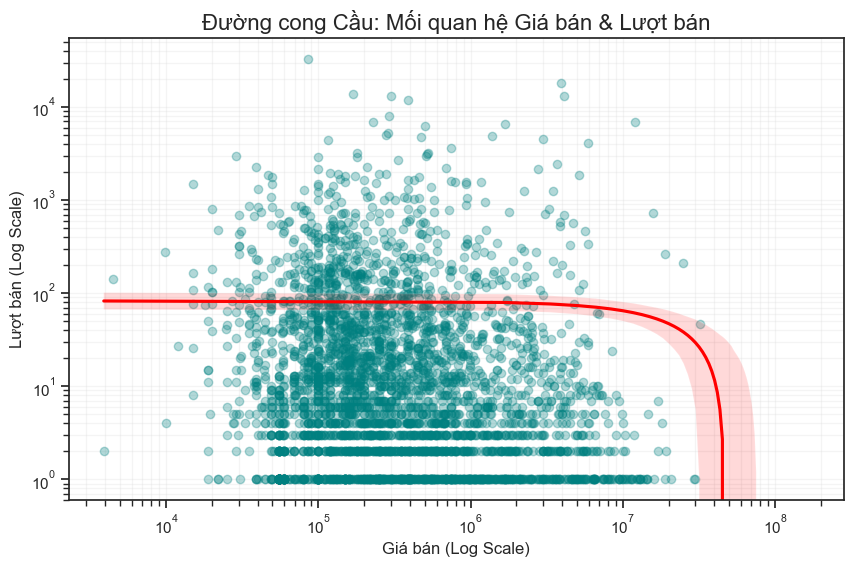

In [9]:
def plot_price_demand_curve(df):
    plt.figure(figsize=(10, 6))
    # Sử dụng regplot để thấy đường xu hướng (Trendline)
    sns.regplot(data=df, x='price_current', y='sold_count', 
                scatter_kws={'alpha':0.3, 'color':'teal'}, 
                line_kws={'color':'red', 'label':'Trendline'})
    
    plt.xscale('log') 
    plt.yscale('log')
    plt.title('Đường cong Cầu: Mối quan hệ Giá bán & Lượt bán')
    plt.xlabel('Giá bán (Log Scale)')
    plt.ylabel('Lượt bán (Log Scale)')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

plot_price_demand_curve(df)

**Nhận xét:**
- Quy luật: Thể hiện rõ mối quan hệ nghịch biến; lượt bán duy trì ổn định ở phân khúc giá thấp và trung bình, nhưng giảm cực mạnh (rơi thẳng đứng) khi giá vượt ngưỡng $10^7$ (10 triệu VND).
- Mật độ: Sản phẩm tập trung dày đặc nhất ở khoảng giá $10^5 - 10^6$ VND, cho thấy đây là phân khúc cạnh tranh khốc liệt nhất.
#### b. Xác định Khoảng giá Tối ưu (Price Binning)

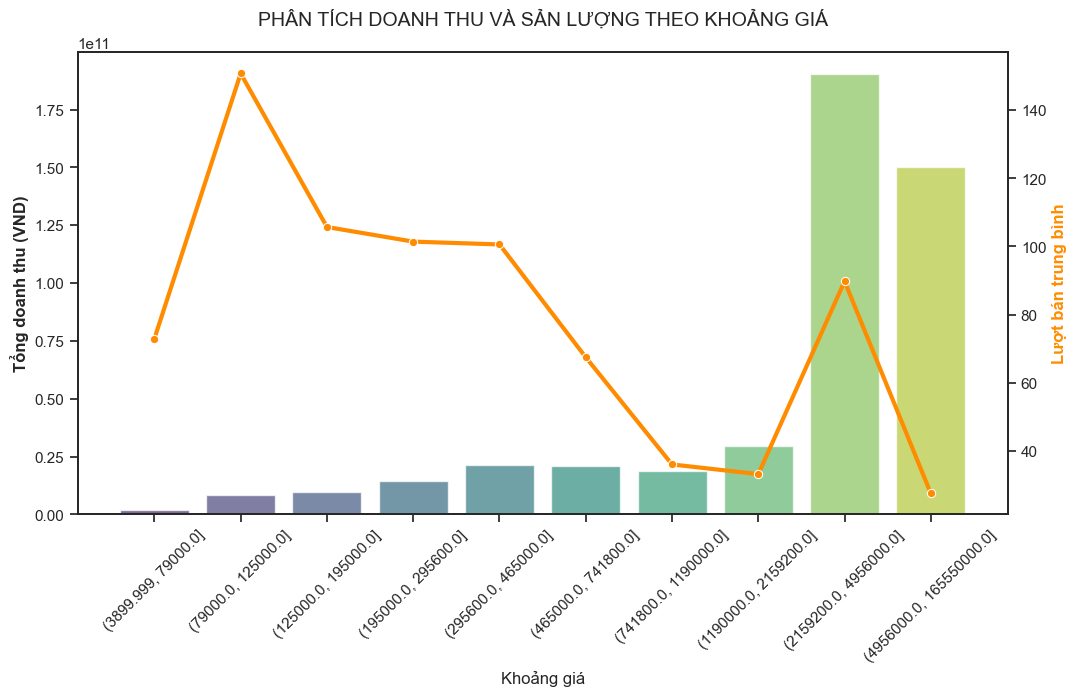

In [10]:
# Tính doanh thu
df['revenue'] = df['price_current'] * df['sold_count']
def plot_revenue_by_bins(df):
    # Chia nhóm giá
    df['price_bin'] = pd.qcut(df['price_current'], q=10, duplicates='drop')
    
    # Groupby 
    bin_analysis = df.groupby('price_bin', observed=False).agg({
        'sold_count': 'mean',
        'revenue': 'sum'
    }).reset_index()
    
    # Chuyển price_bin thành chuỗi để Seaborn
    bin_analysis['price_bin'] = bin_analysis['price_bin'].astype(str)
    
    # Vẽ biểu đồ 
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Cột doanh thu
    sns.barplot(
        data=bin_analysis, 
        x='price_bin', 
        y='revenue', 
        ax=ax1, 
        hue='price_bin',   
        palette='viridis', 
        legend=False,     
        alpha=0.7
    )
    
    ax1.set_ylabel('Tổng doanh thu (VND)', fontweight='bold')
    plt.xticks(rotation=45)
    plt.xlabel("Khoảng giá")

    # Đường lượt bán trung bình 
    ax2 = ax1.twinx()
    sns.lineplot(
        data=bin_analysis, 
        x=range(len(bin_analysis)), 
        y='sold_count', 
        ax=ax2, 
        color='darkorange', 
        marker='o', 
        linewidth=3
    )
    ax2.set_ylabel('Lượt bán trung bình', fontweight='bold', color='darkorange')
    
    plt.title('PHÂN TÍCH DOANH THU VÀ SẢN LƯỢNG THEO KHOẢNG GIÁ', fontsize=14, pad=20)
    
    plt.show()

plot_revenue_by_bins(df)

**Nhận xét:**
- Nghịch lý doanh thu: Dù các nhóm giá rẻ có lượt bán trung bình cao nhất (đường cam cao ở phía trái), nhưng đóng góp vào tổng doanh thu lại rất thấp.
- "Mỏ vàng" doanh thu: Doanh thu thực tế bị chi phối bởi các phân khúc giá cao (từ 2.1 triệu VND trở lên). Hai cột cuối cùng chiếm tỷ trọng áp đảo, chứng tỏ giá trị đơn hàng cao là động lực chính thúc đẩy tăng trưởng doanh số, chứ không phải số lượng đơn hàng.
### 3. Phân tích Đề xuất 2: Tác động của Rating và Review
#### a. Heatmap Tương quan Spearman

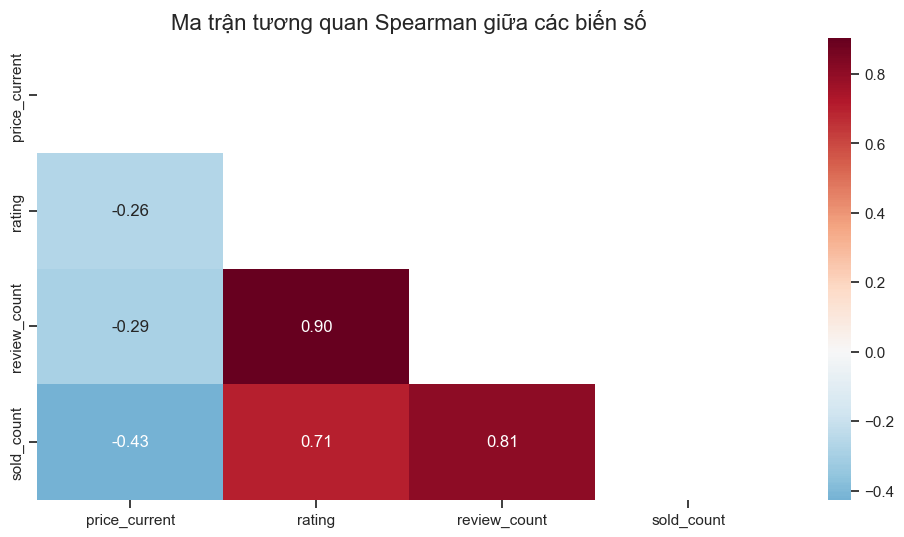

In [11]:
def plot_correlation(df):
    cols = ['price_current', 'rating', 'review_count', 'sold_count']
    corr = df[cols].corr(method='spearman')
    
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
    plt.title('Ma trận tương quan Spearman giữa các biến số')
    plt.show()

plot_correlation(df)

**Nhận xét:**
- Review là yếu tố then chốt: review_count có tương quan với lượt bán mạnh nhất (0.81), cao hơn cả Rating (0.70).
- Sức mạnh cộng hưởng: Tương quan giữa Rating và Review cực cao (0.91), cho thấy uy tín sản phẩm được xây dựng đồng thời từ cả chất lượng và số lượng.
#### b. Hiệu ứng Ngưỡng Rating (Rating Boxplot)

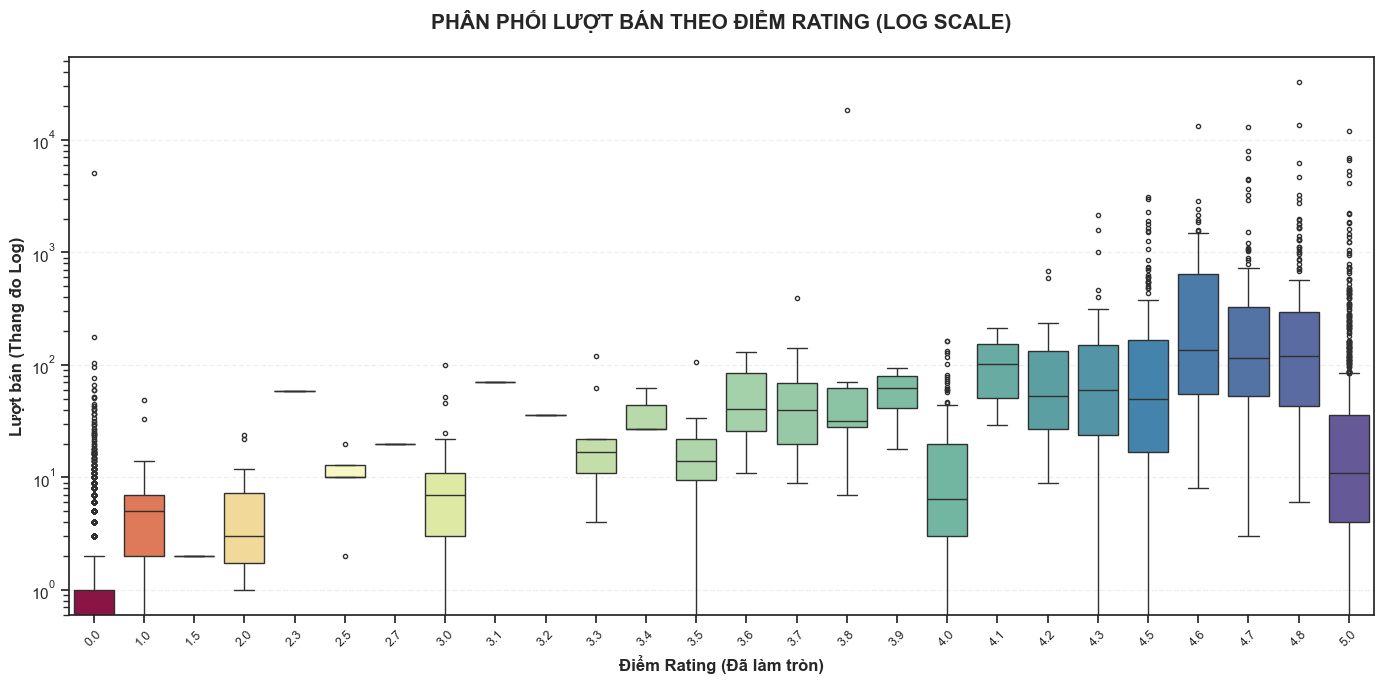

In [13]:
def plot_rating_impact(df):
    df['rating_group'] = df['rating'].round(1)
    
    # Sắp xếp thứ tự các nhóm 
    rating_order = sorted(df['rating_group'].unique())
    
    plt.figure(figsize=(14, 7)) 
    
    # 3. VẼ BIỂU ĐỒ
    sns.boxplot(
        data=df, 
        x='rating_group', 
        y='sold_count', 
        hue='rating_group', 
        order=rating_order, 
        palette='Spectral', 
        legend=False,
        fliersize=3,        
        linewidth=1         
    )
    
    plt.yscale('log') 
    
    plt.xticks(rotation=45, fontsize=9)
    
    plt.title('PHÂN PHỐI LƯỢT BÁN THEO ĐIỂM RATING (LOG SCALE)', fontsize=15, pad=20, fontweight='bold')
    plt.xlabel('Điểm Rating (Đã làm tròn)', fontweight='bold')
    plt.ylabel('Lượt bán (Thang đo Log)', fontweight='bold')
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout() 
    plt.show()

plot_rating_impact(df)

**Nhận xét:**
- Ngưỡng bùng nổ: Lượt bán bắt đầu tăng mạnh và xuất hiện nhiều sản phẩm đột phá (outliers) khi đạt từ 4.3 sao trở lên.
- Bẫy điểm 5.0: Sản phẩm 5 sao tuyệt đối có lượt bán trung bình thấp hơn nhóm 4.7–4.8, do ít review hơn nên chưa tạo được sự tin tưởng tuyệt đối để khách xuống tiền.
#### c. Biểu đồ mật độ (Hexbin Chart)

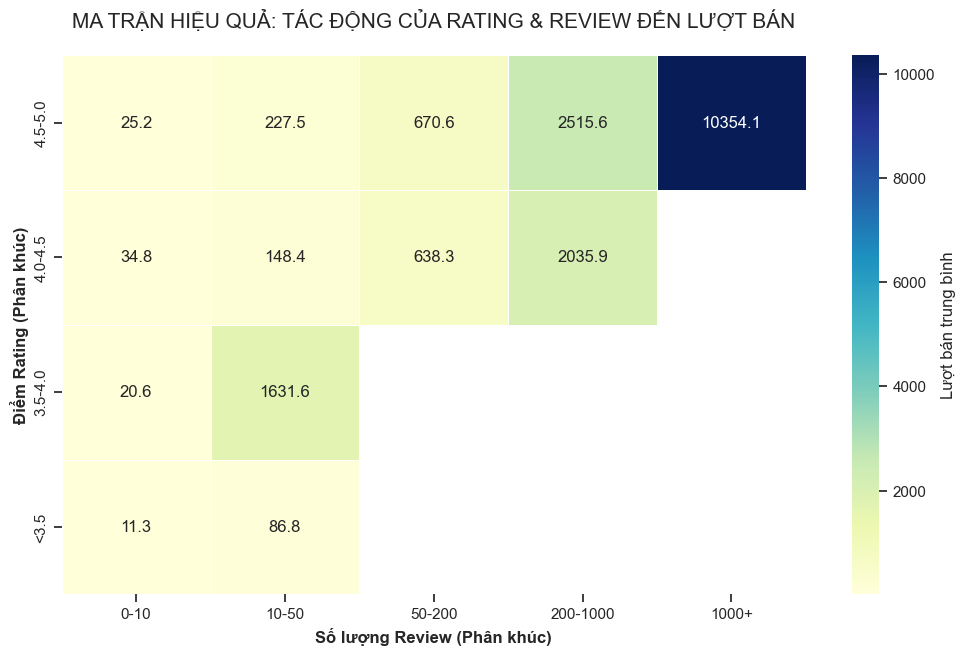

In [ ]:
def plot_rating_review_matrix(df):
    # Chia nhóm Review Count 
    bins_review = [0, 10, 50, 200, 1000, np.inf]
    labels_review = ['0-10', '10-50', '50-200', '200-1000', '1000+']
    df['review_segment'] = pd.cut(df['review_count'], bins=bins_review, labels=labels_review)

    # Chia nhóm Rating 
    bins_rating = [0, 3.5, 4.0, 4.5, 5.0]
    labels_rating = ['<3.5', '3.5-4.0', '4.0-4.5', '4.5-5.0']
    df['rating_segment'] = pd.cut(df['rating'], bins=bins_rating, labels=labels_rating)

    # Tạo bảng Pivot tính Lượt bán trung bình cho từng ô
    pivot_table = df.pivot_table(
        values='sold_count', 
        index='rating_segment', 
        columns='review_segment', 
        aggfunc='mean',
        observed=False
    )

    # Vẽ Heatmap
    plt.figure(figsize=(12, 7))
    sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="YlGnBu", 
                linewidths=.5, cbar_kws={'label': 'Lượt bán trung bình'})

    plt.title('MA TRẬN HIỆU QUẢ: TÁC ĐỘNG CỦA RATING & REVIEW ĐẾN LƯỢT BÁN', fontsize=15, pad=20)
    plt.xlabel('Số lượng Review (Phân khúc)', fontweight='bold')
    plt.ylabel('Điểm Rating (Phân khúc)', fontweight='bold')
    
    plt.gca().invert_yaxis() 
    plt.show()

plot_rating_review_matrix(df)

**Nhận xét:**
- Hiệu ứng số đông: Rating cao là "điều kiện cần", nhưng Review lớn mới là "điều kiện đủ".
- Cột mốc 1000+: Ở cùng nhóm Rating cao, sản phẩm có trên 1000 review đạt lượt bán trung bình (10,354) gấp 4 lần nhóm 200–1000 review và gấp hàng chục lần các nhóm còn lại.